# Whitebox Demo

This notebook demonstrates Whitebox - a model-agnostic visualization library for interpreting ML models by comparing GLM and GBM.

**Key Distinction: Coefficients vs Predictions**

| Parameter | What it Shows | Use Case |
|-----------|---------------|----------|
| `shap=True` | GBM SHAP values (feature effects) | Understand how features influence GBM output |
| `glm=True` | GLM relativities (coefficients) | Compare GLM factors/indications |
| `glm_pred=True` | GLM model predictions | Assess GLM calibration vs actuals |
| `gbm_pred=True` | GBM model predictions | Assess GBM calibration vs actuals |
| `actuals=True` | Observed response values | Ground truth for comparison |

**Contents:**
1. Setup & Data Generation
2. Understanding Model Coefficients/Relativities (SHAP & GLM factors)
3. Comparing Model Predictions vs Actuals
4. Advanced Features (Bivariate, Compare, Config, Engines)

## 1. Setup & Data Generation

First, let's import the required packages and generate synthetic insurance data.

In [1]:
# Standard imports
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Bokeh setup for notebook display
from bokeh.io import output_notebook
output_notebook()

# Import demo modules
from synthetic_data import generate_synthetic_data, train_xgboost_model, prepare_data_for_whitebox
from glm_helpers import get_glm_data_for_whitebox

# Import Whitebox
from whitebox import Whitebox

print("All imports successful!")

Loading BokehJS ...

All imports successful!


In [2]:
# Generate synthetic insurance data
raw_data = generate_synthetic_data(n_samples=10000, random_state=42)

print(f"Generated {len(raw_data):,} samples")
print(f"\nColumns: {list(raw_data.columns)}")
raw_data.head()

Generated 10,000 samples

Columns: ['age', 'vehicle_value', 'years_licensed', 'region', 'vehicle_type', 'exposure', 'claim_count']


,age,vehicle_value,years_licensed,region,vehicle_type,exposure,claim_count
0,52.450712,15689.588755,11.677637,North,SUV,0.639255,0
1,42.926035,18906.296023,24.677705,West,Sedan,0.946568,0
2,54.715328,16338.988603,31.575657,South,SUV,0.989004,0
3,67.845448,23276.720582,45.267958,South,Truck,0.839560,0
4,41.487699,40078.257759,18.461473,West,SUV,0.985150,0


In [3]:
raw_data.dtypes


age               float64
vehicle_value     float64
years_licensed    float64
region             object
vehicle_type       object
exposure          float64
claim_count         int64
dtype: object

## Categorical Variable Encoding for Whitebox

### Why Encoding is Required

GBM models (XGBoost, LightGBM) require **numeric input**, so categorical variables must be encoded as integers. However, for interpretable plots, we need to display **human-readable labels**. Whitebox bridges this gap using `category_mappings`.

### ⚠️ CRITICAL: The `_encoded` Suffix Convention

Whitebox expects encoded columns to follow a **strict naming convention**:

```
{original_column_name}_encoded
```

**Examples:**
- `region` → `region_encoded`
- `vehicle_type` → `vehicle_type_encoded`

**Why this matters:**
- Whitebox automatically detects `_encoded` columns for SHAP calculations
- The GBM model uses `_encoded` columns internally
- Plot labels are generated from the original column + `category_mappings`

### Required Data Structure

For each categorical variable, your DataFrame must have:

| Column | Type | Purpose | Example Values |
|--------|------|---------|----------------|
| `region` | string | Original labels for display | `"North"`, `"South"`, `"East"`, `"West"` |
| `region_encoded` | int | Numeric codes for GBM (must use `_encoded` suffix!) | `0`, `1`, `2`, `3` |

### The `category_mappings` Dictionary

This dictionary maps numeric codes back to labels:

```python
category_mappings = {
    'region': {0: 'East', 1: 'North', 2: 'South', 3: 'West'},
    'vehicle_type': {0: 'SUV', 1: 'Sedan', 2: 'Sports', 3: 'Truck'}
}
```

**Key format:** `{column_name: {code: label, ...}}`

**Important:** Keys in `category_mappings` use the **original column name** (e.g., `'region'`), not the encoded name.

### Option 1: Use `prepare_data_for_whitebox()` (Recommended)

```python
from synthetic_data import prepare_data_for_whitebox

data, category_mappings = prepare_data_for_whitebox(
    raw_data, 
    feature_names,
    optimize=True  # Optional: reduce memory usage
)
```

This automatically:
- Detects string/object columns in `feature_names`
- Creates `{col}_encoded` columns with the correct suffix
- Generates the `category_mappings` dictionary

### Option 2: Manual Encoding

If you have custom encoding requirements, **ensure you use the `_encoded` suffix**:

```python
# 1. Create encoded column WITH THE _encoded SUFFIX
data['region_encoded'] = data['region'].astype('category').cat.codes

# 2. Build category_mappings manually
category_mappings = {
    'region': dict(enumerate(data['region'].astype('category').cat.categories))
}
# Result: {0: 'East', 1: 'North', 2: 'South', 3: 'West'}
```

### Plot Labels: "Label(code)" Format

With `category_mappings`, plots display labels in `"Label(code)"` format:
- `"North(1)"` instead of just `1` or `"North"`
- Makes it easy to trace values back to both the model input and business meaning

In [4]:
# Define feature names (these are the ORIGINAL column names, used for plotting)
feature_names = ['age', 'vehicle_value', 'years_licensed', 'region', 'vehicle_type']

# Prepare data for modeling:
# - Original columns keep human-readable values (for GLM and plot labels)
# - New {col}_encoded columns contain numeric codes (for GBM/XGBoost)
data, category_mappings = prepare_data_for_whitebox(raw_data, feature_names, optimize=True)

print("=" * 70)
print("KEY CONCEPT: GBM vs GLM use different column formats")
print("=" * 70)

print("\n📊 Category mappings (code -> label):")
for col, mapping in category_mappings.items():
    print(f"  {col}: {mapping}")

print("\n" + "-" * 70)
print("GBM (XGBoost) uses ENCODED columns with numeric codes:")
print("-" * 70)
print(data[['region_encoded', 'vehicle_type_encoded']].head())

print("\n" + "-" * 70)
print("GLM uses ORIGINAL columns with string labels:")
print("-" * 70)
print(data[['region', 'vehicle_type']].head())

print("\n✅ Whitebox handles the mapping automatically via category_mappings")

Encoded 2 categorical column(s): ['region', 'vehicle_type']
Encoded columns created: ['region_encoded', 'vehicle_type_encoded']
Optimized 4 numeric column(s):
  age: float64 -> float32
  years_licensed: float64 -> float32
  exposure: float64 -> float32
  claim_count: int64 -> int8
Memory: 1592.4KB -> 1426.4KB (10.4% reduction)
KEY CONCEPT: GBM vs GLM use different column formats

📊 Category mappings (code -> label):
  region: {0: 'East', 1: 'North', 2: 'South', 3: 'West'}
  vehicle_type: {0: 'SUV', 1: 'Sedan', 2: 'Sports', 3: 'Truck'}

----------------------------------------------------------------------
GBM (XGBoost) uses ENCODED columns with numeric codes:
----------------------------------------------------------------------
   region_encoded  vehicle_type_encoded
0               1                     0
1               3                     1
2               2                     0
3               2                     3
4               3                     0

--------------------

In [5]:
# Show the complete data structure
print("Complete DataFrame structure:")
print(f"Columns: {list(data.columns)}")
print(f"\nData types:")
print(data.dtypes)
print(f"\nSample of categorical columns (original vs encoded):")
data[['region', 'region_encoded', 'vehicle_type', 'vehicle_type_encoded']].head(10)

Complete DataFrame structure:
Columns: ['age', 'vehicle_value', 'years_licensed', 'region', 'vehicle_type', 'exposure', 'claim_count', 'region_encoded', 'vehicle_type_encoded']

Data types:
age                     float32
vehicle_value           float64
years_licensed          float32
region                   object
vehicle_type             object
exposure                float32
claim_count                int8
region_encoded             int8
vehicle_type_encoded       int8
dtype: object

Sample of categorical columns (original vs encoded):


,region,region_encoded,vehicle_type,vehicle_type_encoded
0,North,1,SUV,0
1,West,3,Sedan,1
2,South,2,SUV,0
3,South,2,Truck,3
4,West,3,SUV,0
5,South,2,Sedan,1
6,West,3,Sedan,1
7,West,3,Truck,3
8,North,1,Sedan,1
9,North,1,Sedan,1


In [6]:
# Train XGBoost model with Poisson objective
# NOTE: train_xgboost_model automatically uses _encoded columns for categoricals
model = train_xgboost_model(
    data,
    feature_names,  # Pass original names - function uses _encoded columns internally
    weight_col='exposure',
    target_col='claim_count',
    random_state=42,
    max_depth=4,
    eta=0.1
)

print("=" * 70)
print("XGBoost Model Training")
print("=" * 70)
print("\nModel uses ENCODED columns internally:")
print("  - region_encoded (0, 1, 2, 3) instead of ('East', 'North', 'South', 'West')")
print("  - vehicle_type_encoded (0, 1, 2, 3) instead of ('SUV', 'Sedan', 'Sports', 'Truck')")
print("\nFeature importance:")
importance = model.get_score(importance_type='gain')
for feat, score in sorted(importance.items(), key=lambda x: -x[1]):
    print(f"  {feat}: {score:.2f}")

XGBoost Model Training

Model uses ENCODED columns internally:
  - region_encoded (0, 1, 2, 3) instead of ('East', 'North', 'South', 'West')
  - vehicle_type_encoded (0, 1, 2, 3) instead of ('SUV', 'Sedan', 'Sports', 'Truck')

Feature importance:
  age: 1.23
  years_licensed: 1.07
  vehicle_type: 0.80
  vehicle_value: 0.80
  region: 0.67


## 2. Initialize Whitebox

Create a Whitebox instance with our model and data. We'll also set up simulated GLM relativities for comparison.

In [7]:
# Create simulated GLM relativities and predictions
# NOTE: GLM uses the ENCODED columns internally but maps back to original labels
glm_df, glm_preds = get_glm_data_for_whitebox(data, feature_names)

# Add GLM predictions to data
data['glm_predictions'] = glm_preds

print("=" * 70)
print("GLM Relativities (simulated from Emblem-style model)")
print("=" * 70)
print(f"\nGLM columns: {list(glm_df.columns)}")
print(f"GLM predictions - Mean: {glm_preds.mean():.4f}, Actual Mean: {data['claim_count'].mean():.4f}")

print("\n" + "-" * 70)
print("GLM relativities for categorical variables (using encoded values):")
print("-" * 70)
print(f"Region unique GLM values: {glm_df['region'].unique()}")
print(f"Vehicle Type unique GLM values: {glm_df['vehicle_type'].unique()}")

GLM Relativities (simulated from Emblem-style model)

GLM columns: ['age', 'vehicle_value', 'years_licensed', 'region', 'vehicle_type']
GLM predictions - Mean: 0.0894, Actual Mean: 0.0489

----------------------------------------------------------------------
GLM relativities for categorical variables (using encoded values):
----------------------------------------------------------------------
Region unique GLM values: [ 0.    0.05  0.1  -0.05]
Vehicle Type unique GLM values: [ 0.1   0.   -0.05  0.4 ]


In [8]:
glm_df.head()

,age,vehicle_value,years_licensed,region,vehicle_type
0,-0.026164,-0.051856,-0.030197,0.00,0.10
1,0.031476,-0.036936,-0.264199,0.05,0.00
2,-0.039869,-0.048611,-0.388362,0.10,0.10
3,-0.119329,-0.020299,-0.634823,0.10,-0.05
4,0.040181,0.023171,-0.152307,0.05,0.10


In [9]:
# Initialize Whitebox with category_mappings to bridge GBM and GLM
# 
# KEY: category_mappings tells Whitebox how to:
# 1. Use _encoded columns for GBM SHAP calculations
# 2. Map numeric codes back to labels for plotting
# 3. Match GLM relativities with GBM features

print("=" * 70)
print("Initializing Whitebox with category_mappings")
print("=" * 70)

wb = Whitebox(
    data=data,
    model=model,
    weight_col='exposure',
    actuals_col='claim_count',
    feature_names=feature_names,           # Original names (not _encoded)
    link_fn='poisson',
    glm_preds_col='glm_predictions',
    glm_df=glm_df,
    category_mappings=category_mappings,   # Maps codes <-> labels
    verbose=True
)

print("\n" + "-" * 70)
print("Verification:")
print("-" * 70)
print(f"category_mappings stored: {wb.category_mappings}")
print(f"fac_mapping (for plot labels): {wb.fac_mapping}")

Initializing Whitebox with category_mappings
Processed 2 categorical column(s): ['region', 'vehicle_type']

----------------------------------------------------------------------
Verification:
----------------------------------------------------------------------
category_mappings stored: {'region': {0: 'East', 1: 'North', 2: 'South', 3: 'West'}, 'vehicle_type': {0: 'SUV', 1: 'Sedan', 2: 'Sports', 3: 'Truck'}}
fac_mapping (for plot labels): {'region': {0: 'East', 1: 'North', 2: 'South', 3: 'West'}, 'vehicle_type': {0: 'SUV', 1: 'Sedan', 2: 'Sports', 3: 'Truck'}}


In [10]:
data.head()

,age,vehicle_value,years_licensed,region,vehicle_type,exposure,claim_count,region_encoded,vehicle_type_encoded,glm_predictions
0,52.450714,15689.588755,11.677636,North,SUV,0.639255,0.0,1,0,0.076083
1,42.926037,18906.296023,24.677706,West,Sedan,0.946568,0.0,3,1,0.091188
2,54.715328,16338.988603,31.575657,South,SUV,0.989004,0.0,2,0,0.089980
3,67.845451,23276.720582,45.267960,South,Truck,0.839560,0.0,2,3,0.048821
4,41.487698,40078.257759,18.461473,West,SUV,0.985150,0.0,3,0,0.125659


## 2. Understanding Model Coefficients/Relativities

**Story:** *"How does each feature influence my model's output?"*

This section shows how to visualize **feature effects** - how each variable contributes to model predictions. These are NOT the actual predictions, but the learned coefficients/effects:

- **GBM (SHAP values)**: The marginal contribution of each feature value to the prediction
- **GLM (Relativities)**: The multiplicative factors from the linear model

Think of these as the "building blocks" that models use to construct predictions.

In [11]:
# Compute SHAP values (this is also done automatically when plotting)
wb.DataPrep.prep_shap_values()

print("SHAP values computed and cached.")
print(f"\nSHAP DataFrame shape: {wb.shap_df.shape}")
print(f"SHAP columns: {list(wb.shap_df.columns)}")

SHAP values computed and cached.

SHAP DataFrame shape: (10000, 5)
SHAP columns: ['age', 'vehicle_value', 'years_licensed', 'region', 'vehicle_type']


### 2.1 GBM Feature Effects with SHAP

SHAP (SHapley Additive exPlanations) values decompose GBM predictions into per-feature contributions. Use `shap=True` to show the average SHAP value for each bin.

**Key parameters:**
- `shap=True`: Show average SHAP values (the feature effect line)
- `shap_points=True`: Show individual SHAP values as scatter points
- `shap_sd=True`: Show standard deviation bands around the mean

#### Basic SHAP Plot

The simplest view: average SHAP values showing how age affects the GBM's prediction.

In [12]:
# Basic univariate plot showing SHAP values for age
wb.univariate_plot(
    var_name='age',
    shap=True,
    weight=True,
    plot_name='Age - Basic SHAP Plot'
)

Loading BokehJS ...

figure(id='p1002', ...)

#### SHAP with Detail: Points and Standard Deviation

Adding `shap_points=True` shows individual observations, revealing the distribution of SHAP values within each bin. `shap_sd=True` adds +/- 1 standard deviation bands.

In [13]:
# SHAP with individual points and standard deviation bands
wb.univariate_plot(
    var_name='age',
    shap=True,
    shap_points=True,
    shap_sd=True,
    n_shap_points=500,
    weight=True,
    plot_name='Age - SHAP with Points and SD'
)

figure(id='p1097', ...)

### 2.2 GLM Relativities

GLM relativities (also called factors or indications) show the multiplicative effect of each feature level. Use `glm=True` to display these coefficients.

**Note:** `glm=True` shows the GLM *coefficients/relativities*, NOT the model's predictions. This is about understanding the model structure, not its output.

In [14]:
# GLM relativities only - showing the coefficient structure
wb.univariate_plot(
    var_name='age',
    glm=True,
    weight=True,
    plot_name='Age - GLM Relativities (Coefficients)'
)

figure(id='p1207', ...)

### 2.3 Comparing GBM Effects vs GLM Relativities

The real power of Whitebox: overlay SHAP values and GLM relativities on the same plot to see how both models capture feature effects.

**Interpretation:** 
- If lines align: Both models learned similar relationships
- If lines diverge: Models have different views of the feature's effect

In [15]:
# Compare GBM SHAP values with GLM relativities
wb.univariate_plot(
    var_name='age',
    shap=True,
    glm=True,
    weight=True,
    plot_name='Age - GBM Effects (SHAP) vs GLM Relativities'
)

figure(id='p1286', ...)

#### Continuous Variable: Vehicle Value

In [16]:
# Vehicle value - another continuous variable
wb.univariate_plot(
    var_name='vehicle_value',
    shap=True,
    glm=True,
    weight=True,
    nlevels=8,
    percentile_start=5,
    percentile_finish=95,
    plot_name='Vehicle Value - GBM Effects vs GLM Relativities'
)

figure(id='p1405', ...)

In [17]:
# Years licensed - continuous
wb.univariate_plot(
    var_name='years_licensed',
    shap=True,
    glm=True,
    weight=True,
    plot_name='Years Licensed - GBM Effects vs GLM Relativities'
)

figure(id='p1524', ...)

#### Categorical Variables: Region and Vehicle Type

For categorical variables, both models show effects per level:
- **GBM SHAP**: Computed using `{col}_encoded`, then mapped back to labels
- **GLM Relativities**: The multiplicative factor for each category

In [18]:
# Region - categorical variable
wb.univariate_plot(
    var_name='region',
    shap=True,
    glm=True,
    weight=True,
    plot_name='Region - GBM Effects vs GLM Relativities'
)

figure(id='p1643', ...)

In [19]:
# Vehicle type - categorical variable  
wb.univariate_plot(
    var_name='vehicle_type',
    shap=True,
    glm=True,
    weight=True,
    plot_name='Vehicle Type - GBM Effects vs GLM Relativities'
)

figure(id='p1762', ...)

## 3. Comparing Model Predictions vs Actuals

**Story:** *"How well do my models predict actual outcomes?"*

Now we shift from **coefficients** (how features affect predictions) to **predictions** (what the models actually output).

| Parameter | Shows |
|-----------|-------|
| `glm_pred=True` | GLM model's predicted values |
| `gbm_pred=True` | GBM model's predicted values |
| `actuals=True` | Observed response values (ground truth) |

**Use case:** Assess model calibration - are predictions aligned with actuals across feature values?

In [20]:
# GLM Predictions vs Actuals
# glm_pred=True shows what the GLM actually predicts (NOT the relativities!)
wb.univariate_plot(
    var_name='age',
    glm_pred=True,
    gbm_pred=True,
    actuals=True,
    weight=True,
    plot_name='Age - GLM Predictions vs Actuals'
)

figure(id='p1881', ...)

### 3.1 GLM Predictions for Different Variables

# GLM predictions for vehicle_value
wb.univariate_plot(
    var_name='vehicle_value',
    glm_pred=True,
    actuals=True,
    weight=True,
    nlevels=8,
    plot_name='Vehicle Value - GLM Predictions vs Actuals'
)

In [21]:
# GLM predictions for categorical variable
wb.univariate_plot(
    var_name='region',
    glm_pred=True,
    gbm_pred=True,
    actuals=True,
    weight=True,
    plot_name='Region - GLM Predictions vs Actuals'
)

figure(id='p2008', ...)

### 3.2 GBM Predictions in Bivariate Plots

For GBM predictions, use `gbm_pred=True` in bivariate plots to see how predictions vary across two dimensions.

In [30]:
# GBM predictions by age and region
wb.bivariate_plot(
    var1='age',
    var2='region',
    gbm_pred=True,
    actuals=True,
    nlevels_var1=6,
    plot_title='Age x Region - GBM Predictions vs Actuals'
)

figure(id='p3905', ...)

In [31]:
# GBM predictions by vehicle value and type
wb.bivariate_plot(
    var1='vehicle_value',
    var2='vehicle_type',
    gbm_pred=True,
    actuals=True,
    nlevels_var1=6,
    plot_title='Vehicle Value x Type - GBM Predictions vs Actuals'
)

figure(id='p4248', ...)

### 3.3 Full Predictions Comparison

Combine GLM predictions, actuals, and weights on a single plot to assess overall calibration.

In [33]:
# Complete calibration view: GLM predictions vs actuals with weight distribution
wb.univariate_plot(
    var_name='age',
    gbm_pred=True,
    glm_pred=True,
    actuals=True,
    weight=True,
    plot_name='Age - Full Calibration View'
)

figure(id='p4694', ...)

## 4. Advanced Features

### 4.1 Bivariate Plots with SHAP (Feature Interactions)

Bivariate plots show how feature interactions are captured by the models.

In [34]:
# Bivariate: Age x Vehicle Value SHAP interaction
wb.bivariate_plot(
    var1='age',
    var2='vehicle_value',
    shap=True,
    nlevels_var1=6,
    nlevels_var2=4,
    plot_title='Age x Vehicle Value - SHAP Interactions'
)

figure(id='p4821', ...)

In [35]:
# Bivariate: SHAP with GLM comparison
wb.bivariate_plot(
    var1='age',
    var2='region',
    shap=True,
    glm=True,
    nlevels_var1=6,
    plot_title='Age x Region - SHAP vs GLM'
)

figure(id='p4996', ...)

### 4.2 Model Comparison

Compare multiple GBM models side by side using the `compare()` method.

In [36]:
# Train a second model with different hyperparameters
model2 = train_xgboost_model(
    data,
    feature_names,
    weight_col='exposure',
    target_col='claim_count',
    random_state=123,
    max_depth=6,  # Deeper trees
    eta=0.05      # Lower learning rate
)

# Create second Whitebox instance
wb2 = Whitebox(
    data=data,
    model=model2,
    weight_col='exposure',
    actuals_col='claim_count',
    feature_names=feature_names,
    link_fn='poisson',
    category_mappings=category_mappings,
    verbose=False
)

print("Second model trained and Whitebox instance created!")

Second model trained and Whitebox instance created!


# Compare models on age variable
wb.compare(
    wblist=[wb2],
    model_names=['Model 1 (depth=4)', 'Model 2 (depth=6)'],
    var_name='age',
    shap=True,
    weight=True,
    plot_name='Model Comparison - Age'
)

### 4.3 Configuration Customization

Customize plot appearance through the `config` dictionary.

In [37]:
# View default configuration
import json
print("Default configuration:")
print(json.dumps(wb.config, indent=2))

Default configuration:
{
  "labels": {
    "glm": "GLM indication",
    "shap": "Avg SHAP",
    "shap_points": "SHAP",
    "shap_sd": "SHAP +/- SD",
    "glm_pred": "GLM prediction",
    "gbm_pred": "GBM prediction",
    "actuals": "Actuals",
    "weight": "Weight",
    "glm_ci": "GLM pred +/-"
  },
  "colors": {
    "glm": "green",
    "shap": "#3182bd",
    "shap_sd": "#3182bd",
    "shap_points": "#6baed6",
    "glm_pred": "purple",
    "gbm_pred": "silver",
    "actuals": "red",
    "weight": "orange"
  },
  "line_width": {
    "glm": 2,
    "shap": 2,
    "shap_points": null,
    "glm_pred": 1,
    "gbm_pred": 1,
    "actuals": 1,
    "shap_sd": 0.5,
    "weight": null
  },
  "marker": {
    "glm": "s",
    "shap": "s",
    "shap_points": "s",
    "glm_pred": "s",
    "gbm_pred": "s",
    "actuals": "s",
    "weight": "s"
  }
}


In [38]:
# Create Whitebox with custom styling
wb_custom = Whitebox(
    data=data,
    model=model,
    weight_col='exposure',
    actuals_col='claim_count',
    feature_names=feature_names,
    link_fn='poisson',
    glm_preds_col='glm_predictions',
    glm_df=glm_df,
    category_mappings=category_mappings,
    shap_df=wb.shap_df,  # Reuse computed SHAP values
    verbose=False
)

# Customize colors and labels
wb_custom.config['colors']['shap'] = '#e41a1c'       # Red
wb_custom.config['colors']['glm'] = '#4daf4a'        # Green
wb_custom.config['labels']['shap'] = 'GBM Effect'
wb_custom.config['labels']['glm'] = 'GLM Factor'
wb_custom.config['line_width']['shap'] = 3

# Plot with custom styling
wb_custom.univariate_plot(
    var_name='age',
    shap=True,
    glm=True,
    weight=True,
    plot_name='Age - Custom Styled Plot'
)

figure(id='p5243', ...)

### 4.4 Plot Engines

Whitebox supports two plot engines: **Bokeh** (interactive) and **Matplotlib** (static).

#### Bokeh (Default - Interactive)

In [39]:
# Bokeh - produces interactive HTML plots with tooltips
wb.univariate_plot(
    var_name='years_licensed',
    shap=True,
    glm=True,
    weight=True,
    engine='Bokeh',
    plot_name='Years Licensed - Bokeh (Interactive)'
)

figure(id='p5362', ...)

#### Matplotlib (Static - for reports/PDFs)

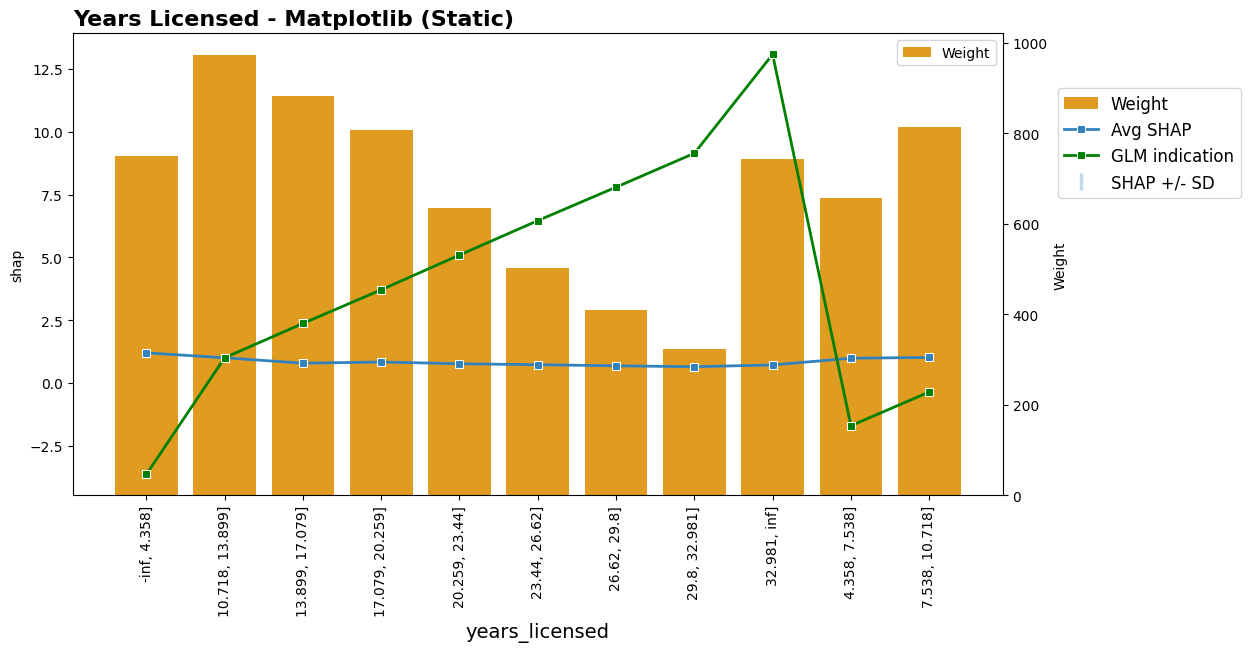

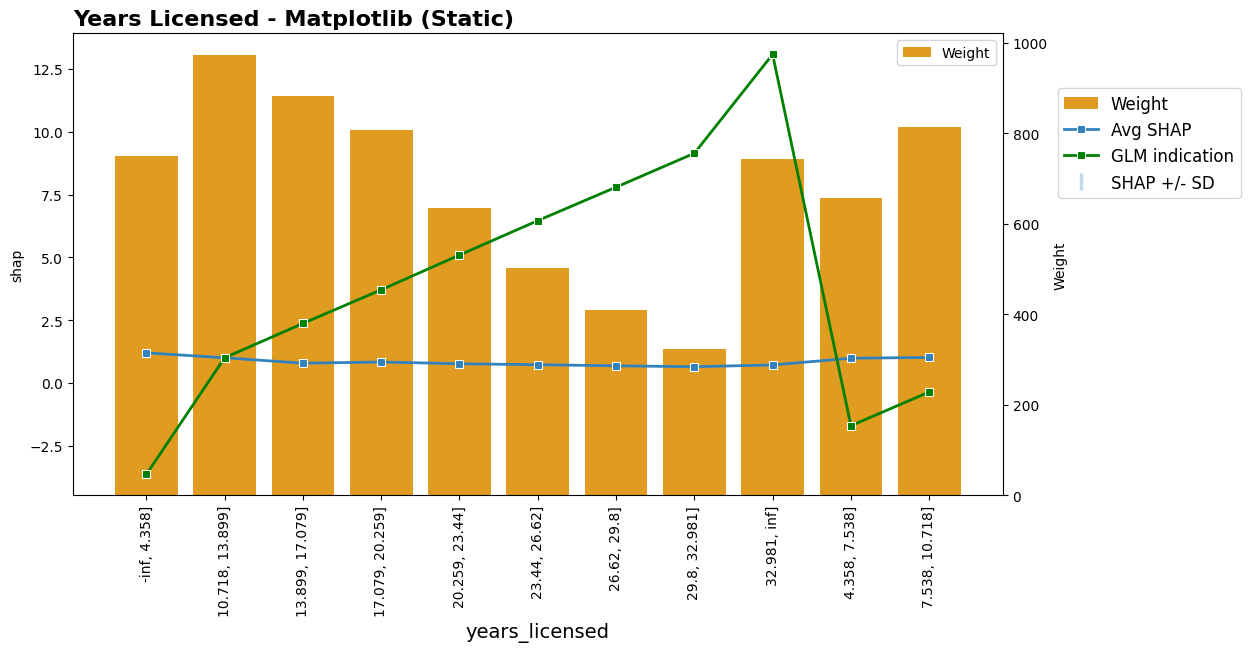

In [40]:
# Matplotlib - static plots for reports and PDFs
wb.univariate_plot(
    var_name='years_licensed',
    shap=True,
    glm=True,
    weight=True,
    engine='Matplotlib',
    plot_name='Years Licensed - Matplotlib (Static)'
)

## Summary

### Key Distinctions Recap

| Parameter | What it Shows | Use Case |
|-----------|---------------|----------|
| `shap=True` | GBM SHAP values (feature effects) | Understand how features influence GBM predictions |
| `glm=True` | GLM relativities (coefficients) | Compare GLM factors/indications |
| `glm_pred=True` | GLM model predictions | Assess GLM calibration vs actuals |
| `gbm_pred=True` | GBM model predictions | Assess GBM calibration vs actuals |
| `actuals=True` | Observed response values | Ground truth for comparison |

### This Demo Covered

1. **Setup**: Data generation, categorical encoding, model training
2. **Coefficients/Relativities**: SHAP values (`shap=True`) and GLM factors (`glm=True`)
3. **Predictions vs Actuals**: Model output comparison (`glm_pred`, `gbm_pred`, `actuals`)
4. **Advanced Features**: Bivariate plots, model comparison, customization, plot engines

For more details, see the Whitebox documentation and the CLAUDE.md file in the repository root.